In [26]:
import os, json, time, re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

True

In [27]:
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if OPENROUTER_API_KEY is None:
    raise ValueError("OPENROUTER_API_KEY is not set")

In [28]:
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

In [29]:
df = pd.read_csv(r"F:\Thesis\project\403-vekalat\structured_questions.csv")
df.head(3)

,question_number,category,question,options
0,1,حقوق مدنی,کدام یک از موارد زیر صحیح است؟,1) با توافق طرفین امکان از بین بردن سبب انفساخ...
1,2,حقوق مدنی,شخص «الف» حین رانندگی با خودرو سواری با شخص «ب...,1) دیه هر دو راننده صرفاً تا میزان دیه کامل و ...
2,3,حقوق مدنی,کدام مورد در خصوص تصرفی که همراه با قصد تملک ب...,1) تصرف در مواردی مملک است حتی اگر همراه با قص...


In [30]:
def to_list(opts):
    if isinstance(opts, list): return opts
    if isinstance(opts, str):
        try:
            v = json.loads(opts)
            if isinstance(v, list): return v
        except Exception: pass
        for sep in ["|","؛",";","/","\\","،","\n"]:
            if sep in opts: return [x.strip() for x in opts.split(sep) if x.strip()]
        return [opts.strip()]
    return [str(opts)]

In [31]:
def render_numeric_options(opts):
    return "\n".join(f"{i+1}) {o}" for i, o in enumerate(opts))

In [32]:
def build_messages(question: str, options_text: str):
    return [
        {
            "role": "system",
            "content": (
                "# Iranian Legal Question Answering System\n"
                "You are a professional legal reasoning assistant specialized in Iranian law.\n"
                "---\n"
                "## Task:\n"
                "- Language: Persian (فارسی)\n"
                "- Objective: Analyze the question under Iranian law and select the correct option number.\n"
                "- Provide a **short legal explanation (1–2 sentences in Persian)** describing:\n"
                "  1. Which legal article, principle, or rule applies.\n"
                "  2. Why that rule leads to the chosen answer.\n"
                "- Only explain why the correct option is right (do not discuss wrong options).\n"
                "- After the explanation, give your prediction in valid JSON format.\n"
                "---\n"
                "## Confidence Scale (5 Levels):\n"
                "- 1: UNCERTAIN — Cannot distinguish between two or more options.\n"
                "- 2: WEAK — Significant doubt or debatable interpretation.\n"
                "- 3: MODERATE — Fairly confident; based on a standard or commonly accepted interpretation.\n"
                "- 4: STRONG — Confident; clear legal article, rule, or precedent supports the choice.\n"
                "- 5: VERY STRONG — Certain; unambiguous and directly supported by law.\n"
                "\n"
                "⚠️ Most questions should result in scores between 2 and 4.\n"
                "---\n"
                "## Output Format:\n"
                "Return a single valid JSON object in this exact format:\n"
                '{"explanation":"توضیح کوتاه حقوقی شامل ماده یا قاعده و استدلال","answer":"X","confidence":Y}\n'
                "- explanation: concise reasoning (in Persian, max 2 sentences, cite relevant article or rule)\n"
                "- answer: one of \"1\",\"2\",\"3\",\"4\" (the correct option number)\n"
                "- confidence: one of {1,2,3,4,5} as defined above\n"
                "---\n"
                "Output only the raw JSON without any extra text, markdown, or formatting."
            )
        },
        {
            "role": "user",
            "content": f"""Question:
{question}

Options:
{options_text}

Required output format:
{{"explanation":"توضیح کوتاه حقوقی شامل ماده یا قاعده و استدلال","answer":"شماره_گزینه","confidence":میزان_اطمینان}}"""
        }
    ]


In [33]:
def extract_json(content: str, verbose: bool = False):
    """
    Extract the last valid JSON object from an LLM response.
    Supports schemas with keys: explanation, answer, confidence.
    """
    import json, re

    if not content or not str(content).strip():
        if verbose:
            print("⚠️ Content is empty or None")
        return None

    content = str(content).strip()

    # Remove markdown code fences ``````
    if content.startswith("```"):
        lines = content.split("\n")
        if lines and lines.strip().startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        content = "\n".join(lines).strip()

    # Attempt 1: Direct parse (whole content is JSON)
    try:
        parsed = json.loads(content)
        if verbose:
            print(f"✓ Direct parse successful: {parsed}")
        return parsed
    except json.JSONDecodeError as e:
        if verbose:
            print(f"⚠️ Direct parse failed: {e}")

    # Attempt 2: Regex extraction of ALL JSON objects, return the LAST valid
    # This pattern tolerates nested braces one level; sufficient for flat objects.
    pattern = r'\{(?:[^{}]|(?:\{[^{}]*\}))*\}'
    candidates = [m.group(0).strip() for m in re.finditer(pattern, content, re.DOTALL)]

    last_valid = None
    for cand in candidates:
        try:
            obj = json.loads(cand)
            last_valid = obj  # keep overwriting to end up with the last one
        except json.JSONDecodeError:
            if verbose:
                print(f"⚠️ Invalid JSON candidate: {cand[:120]}...")
            continue

    if last_valid is not None:
        if verbose:
            print(f"✓ Regex extraction successful (last JSON): {last_valid}")
        return last_valid

    # Attempt 3: Manual fallback – extract fields individually
    # explanation (optional)
    expl_match = re.search(r'"explanation"\s*:\s*"(?P<exp>(?:\\.|[^"\$$)*)"', content)
    explanation = expl_match.group("exp").strip() if expl_match else ""

    # answer (required)
    ans_match = re.search(r'"answer"\s*:\s*"(?P<ans>\d+)"', content)
    # confidence (required)
    conf_match = re.search(r'"confidence"\s*:\s*(?P<conf>-?\d+(?:\.\d+)?)', content)

    if ans_match and conf_match:
        conf_raw = conf_match.group("conf")
        try:
            confidence = int(float(conf_raw))
        except Exception:
            confidence = None

        fallback = {
            "explanation": explanation,
            "answer": ans_match.group("ans"),
            "confidence": confidence
        }
        if verbose:
            print(f"✓ Manual extraction successful: {fallback}")
        return fallback

    if verbose:
        preview = content if len(content) < 200 else content[:200] + "..."
        print(f"⚠️ No valid JSON found in content:\n{preview}")
    return None


In [34]:
VALID_CONFIDENCE = {1, 2, 3, 4, 5}

def call_model(
    client,
    model: str, 
    messages, 
    temperature: float = 0.1, 
    max_tokens: int = 1024,
    valid_answers: set = None,
    verbose: bool = False,
    timeout: float = 60.0,
    stop: list | None = None,
):
    """
    Stable call: extracts explanation, answer, confidence, and token usage.
    Returns:
        dict: {
            "answer": str | None,
            "confidence": int | None,
            "explanation": str,
            "raw": str,
            "latency_ms": int | None,
            "prompt_tokens": int | None,
            "completion_tokens": int | None,
            "total_tokens": int | None,
            "explain_len_chars": int | None,
            "explain_len_words": int | None,
            "error": str | None
        }
    """
    if valid_answers is None:
        valid_answers = {"1", "2", "3", "4"}

    t0 = time.time()
    content = None

    try:
        # --- Model Call ---
        resp = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            timeout=timeout,
            stop=stop,
        )

        latency = int((time.time() - t0) * 1000)

        # --- Extract content safely ---
        choice0 = resp.choices[0]
        content = (
            getattr(choice0, "message", None).content if getattr(choice0, "message", None) else None
        ) or getattr(choice0, "text", None)

        if not content or not str(content).strip():
            raise ValueError("Model returned no text content")

        content = str(content).strip()

        # --- Usage tokens (may be None if provider doesn't return) ---
        usage = getattr(resp, "usage", None)
        prompt_tokens     = getattr(usage, "prompt_tokens", None) if usage else None
        completion_tokens = getattr(usage, "completion_tokens", None) if usage else None
        total_tokens      = getattr(usage, "total_tokens", None) if usage else None

        if verbose:
            finish_reason = getattr(choice0, "finish_reason", None)
            print(f"\n🔍 Model: {model} | Latency: {latency} ms | finish_reason: {finish_reason} | usage: {getattr(usage, '__dict__', usage)}")
            print(f"🔍 Raw output preview:\n{content[:200]}...\n")

        # --- Extract JSON structure (supports explanation/answer/confidence) ---
        data = extract_json(content, verbose=verbose)
        if not data:
            raise ValueError("Failed to extract valid JSON structure from model output")

        # --- Parse fields ---
        explanation = str(data.get("explanation", "") or "").strip()
        explain_len_chars = len(explanation) if explanation else 0
        explain_len_words = len(explanation.split()) if explanation else 0

        answer = str(data.get("answer", "")).strip().strip('"').strip("'")
        if answer not in valid_answers:
            raise ValueError(f"Invalid answer '{answer}', expected one of {valid_answers}")

        conf_raw = data.get("confidence", None)
        if conf_raw is None:
            raise ValueError("Missing 'confidence' field in model output")

        try:
            confidence = int(conf_raw)
        except Exception:
            try:
                confidence = int(float(str(conf_raw).strip()))
            except Exception:
                raise ValueError(f"Invalid confidence value: {conf_raw}")

        if confidence not in VALID_CONFIDENCE:
            original = confidence
            confidence = min(VALID_CONFIDENCE, key=lambda x: abs(x - original))
            if verbose:
                print(f"⚠️ Adjusted confidence from {original} → {confidence}")

        if verbose:
            print(f"✅ Parsed → answer={answer}, confidence={confidence}, explain_len(chars)={explain_len_chars}, tokens: p={prompt_tokens}, c={completion_tokens}, t={total_tokens}")

        return {
            "answer": answer,
            "confidence": confidence,
            "explanation": explanation,
            "raw": content,
            "latency_ms": latency,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": total_tokens,
            "explain_len_chars": explain_len_chars,
            "explain_len_words": explain_len_words,
            "error": None,
        }

    except Exception as e:
        latency = int((time.time() - t0) * 1000)
        if verbose:
            print(f"❌ Error: {str(e)}")
            if content:
                print(f"❌ Raw content preview:\n{str(content)[:300]}...\n")

        return {
            "answer": None,
            "confidence": None,
            "explanation": "",
            "raw": content or "",
            "latency_ms": latency,
            "prompt_tokens": None,
            "completion_tokens": None,
            "total_tokens": None,
            "explain_len_chars": None,
            "explain_len_words": None,
            "error": str(e),
        }


In [35]:
def run_zero_shot_e2p(
    client,
    model: str,
    df,
    limit=None,
    verbose: bool = False
):
    """
    Run zero-shot evaluation on questions (single run per question).

    Returns:
        pd.DataFrame with columns:
            - id, model, answer, confidence, explanation, latency_ms,
              prompt_tokens, completion_tokens, total_tokens,
              explain_len_chars, explain_len_words,
              raw, error
    """
    rows = []
    errors = []

    iterator = tqdm(df.iterrows(), total=len(df), desc=f"Zero-Shot({model})", disable=verbose)

    processed = 0
    for idx, row in iterator:
        if limit is not None and processed >= int(limit):
            break

        qid = row.get("question_number", idx)

        try:
            q = row["question"]
            opts_list = to_list(row["options"])
            options_text = render_numeric_options(opts_list)
            messages = build_messages(q, options_text)

            if verbose:
                print(f"\n📝 Q{qid}: {str(q)[:60]}...")

            # CoT به فضای بیشتری نیاز دارد
            result = call_model(
                client=client,
                model=model,
                messages=messages,
                temperature=0.1,
                max_tokens=1024,          # فضای کافی برای explain + JSON
                timeout=60.0,             # پایداری بهتر
                verbose=verbose
            )

            rec = {
                "id": qid,
                "model": model,
                "answer": result.get("answer"),
                "confidence": result.get("confidence"),
                "explanation": result.get("explanation", ""),
                "latency_ms": result.get("latency_ms"),
                "prompt_tokens": result.get("prompt_tokens"),
                "completion_tokens": result.get("completion_tokens"),
                "total_tokens": result.get("total_tokens"),
                "explain_len_chars": result.get("explain_len_chars"),
                "explain_len_words": result.get("explain_len_words"),
                "raw": result.get("raw", ""),
                "error": result.get("error"),
            }
            rows.append(rec)
            processed += 1

        except Exception as e:
            if verbose:
                print(f"❌ Q{qid}: {str(e)}")
            errors.append({"id": qid, "error": str(e)})

            rows.append({
                "id": qid,
                "model": model,
                "answer": None,
                "confidence": None,
                "explanation": "",
                "latency_ms": None,
                "prompt_tokens": None,
                "completion_tokens": None,
                "total_tokens": None,
                "explain_len_chars": None,
                "explain_len_words": None,
                "raw": "",
                "error": str(e)
            })
            processed += 1
            continue

    if errors and verbose:
        print(f"\n⚠️  {len(errors)} questions had errors")

    df_out = pd.DataFrame(rows)

    desired_cols = [
        "id","model","answer","confidence","explanation","latency_ms",
        "prompt_tokens","completion_tokens","total_tokens",
        "explain_len_chars","explain_len_words",
        "raw","error"
    ]
    df_out = df_out[[c for c in desired_cols if c in df_out.columns]]

    return df_out


In [36]:
# ================== شروع اجرا ==================
print("="*70)
print("🚀 Zero-Shot Evaluation")
print("="*70)
print(f"📂 Dataset size: {len(df)} questions")
print(f"📊 Model: TNG: DeepSeek R1T2 Chimera")
print("="*70 + "\n")

start_time = time.time()

try:
    # اجرا
    results = run_zero_shot_e2p(
        client=client,
        model="tngtech/deepseek-r1t2-chimera:free",
        df=df,
        limit=None,   # None = همه
        verbose=True # توصیه: False برای سرعت؛ چند تست اول را True کن
    )

    elapsed = time.time() - start_time

    # ================== خلاصه نتایج ==================
    print("\n" + "="*70)
    print("✅ Execution Completed!")
    print("="*70)
    print(f"📊 Processed: {len(results)} questions")
    print(f"⏱️  Total time: {elapsed/60:.1f} minutes ({elapsed:.1f} seconds)")
    print(f"⚡ Avg time per question: {elapsed/len(results):.2f} seconds")

    # ================== آمار کلیدی ==================
    print("\n" + "="*70)
    print("📈 Summary Statistics")
    print("="*70)
    
    # Confidence آمار
    if "confidence" in results.columns:
        valid_conf = results["confidence"].dropna()
        if len(valid_conf) > 0:
            avg_conf = valid_conf.mean()
            print(f"   Average confidence: {avg_conf:.1f}")
            print(f"   Median confidence: {valid_conf.median():.1f}")
            print(f"   Min confidence: {valid_conf.min():.1f}")
            print(f"   Max confidence: {valid_conf.max():.1f}")

            total = len(results)
            very_low = (valid_conf <= 2).sum()
            low      = ((valid_conf > 2) & (valid_conf <= 3)).sum()
            medium   = ((valid_conf > 3) & (valid_conf <= 4)).sum()
            high     = (valid_conf > 4).sum()

            print(f"\n   Very Low (≤2): {very_low} ({very_low/total*100:.1f}%)")
            print(f"   Low (2-3): {low} ({low/total*100:.1f}%)")
            print(f"   Medium (3-4): {medium} ({medium/total*100:.1f}%)")
            print(f"   High (>4): {high} ({high/total*100:.1f}%)")

    # توزیع پاسخ‌ها
    if "answer" in results.columns:
        print(f"\n   Answer distribution:")
        answer_dist = results["answer"].value_counts().sort_index()
        for ans, count in answer_dist.items():
            print(f"      {ans}: {count} ({count/len(results)*100:.1f}%)")

    # خطاها
    if "error" in results.columns:
        errors_count = (results["error"].notna()).sum()
        if errors_count > 0:
            print(f"\n   ⚠️  Questions with errors: {errors_count} ({errors_count/len(results)*100:.1f}%)")
        else:
            print(f"\n   ✅ No errors!")

    # Latency آمار
    if "latency_ms" in results.columns:
        valid_latency = results["latency_ms"].dropna()
        if len(valid_latency) > 0:
            print(f"\n   Average latency: {valid_latency.mean():.0f}ms")
            print(f"   Median latency:  {valid_latency.median():.0f}ms")
            print(f"   Max latency:     {valid_latency.max():.0f}ms")

    # ================== آمار مبتنی بر توکن‌ها ==================
    print("\n" + "="*70)
    print("🔎 Token-based Analysis")
    print("="*70)

    have_tokens = {"prompt_tokens","completion_tokens","total_tokens"}.issubset(results.columns)
    if have_tokens:
        # خلاصه
        for col in ["prompt_tokens","completion_tokens","total_tokens"]:
            s = results[col].dropna()
            if len(s) > 0:
                print(f"   {col}: mean={s.mean():.1f}, median={s.median():.1f}, min={s.min()}, max={s.max()}")

        # همبستگی با confidence
        if "confidence" in results.columns:
            subset = results.dropna(subset=["confidence","completion_tokens"])
            if len(subset) > 1:
                corr_p = subset[["completion_tokens","confidence"]].corr(method="pearson").iloc[0,1]
                corr_s = subset[["completion_tokens","confidence"]].corr(method="spearman").iloc[0,1]
                print(f"\n   Correlation (Pearson) completion_tokens ~ confidence: {corr_p:.3f}")
                print(f"   Correlation (Spearman) completion_tokens ~ confidence: {corr_s:.3f}")

        # همبستگی latency با توکن‌ها
        if "latency_ms" in results.columns:
            subset = results.dropna(subset=["latency_ms","completion_tokens"])
            if len(subset) > 1:
                corr_lp = subset[["completion_tokens","latency_ms"]].corr(method="pearson").iloc[0,1]
                print(f"   Correlation (Pearson) completion_tokens ~ latency_ms: {corr_lp:.3f}")

        # توکن‌ها به تفکیک پاسخ
        if "answer" in results.columns:
            by_ans = results.dropna(subset=["answer","completion_tokens"]).copy()
            if len(by_ans) > 0:
                print("\n   Completion tokens by answer (mean):")
                means = by_ans.groupby(by_ans["answer"].astype(str))["completion_tokens"].mean()
                for ans, m in means.sort_index().items():
                    print(f"      {ans}: {m:.1f}")

        # طول explain و اعتماد
        if {"explain_len_words","confidence"}.issubset(results.columns):
            sub = results.dropna(subset=["explain_len_words","confidence"])
            if len(sub) > 1:
                corr_ep = sub[["explain_len_words","confidence"]].corr(method="pearson").iloc[0,1]
                corr_es = sub[["explain_len_words","confidence"]].corr(method="spearman").iloc[0,1]
                print(f"\n   Correlation explain_len_words ~ confidence: Pearson={corr_ep:.3f}, Spearman={corr_es:.3f}")
    else:
        print("   ⚠️ Token usage columns not found. Ensure call_model returns prompt/completion/total tokens.")

    # ================== ذخیره نتایج ==================
    print("\n" + "="*70)
    print("💾 Saving Results")
    print("="*70)

    # CSV
    csv_filename = "results_zero_shot.csv"
    results.to_csv(csv_filename, index=False, encoding="utf-8-sig")
    print(f"   ✅ CSV saved: {csv_filename}")

    # Excel
    excel_filename = "results_zero_shot.xlsx"
    with pd.ExcelWriter(excel_filename, engine="openpyxl") as writer:
        # Summary: ستون‌های کلیدی اگر موجود باشند
        summary_cols = [c for c in [
            "id","answer","confidence","explanation","latency_ms","error",
            "completion_tokens","prompt_tokens","total_tokens","explain_len_words"
        ] if c in results.columns]
        results[summary_cols].to_excel(writer, sheet_name="Summary", index=False)
        results.to_excel(writer, sheet_name="Details", index=False)
    print(f"   ✅ Excel saved: {excel_filename}")

    # ================== نمایش نمونه ==================
    print("\n" + "="*70)
    print("📋 Sample Results (First 10)")
    print("="*70)
    display_cols = [c for c in [
        "id","answer","confidence","explanation","latency_ms","error",
        "completion_tokens","prompt_tokens","total_tokens","explain_len_words"
    ] if c in results.columns]
    print(results[display_cols].head(10).to_string(index=False))

    # ================== سؤالات با خطا ==================
    if "error" in results.columns:
        error_rows = results[results["error"].notna()]
        if len(error_rows) > 0:
            print("\n" + "="*70)
            print("⚠️  Questions with Errors")
            print("="*70)
            print(error_rows[["id","error"]].head(10).to_string(index=False))

    print("\n" + "="*70)
    print("🎉 All Done!")
    print("="*70)

except KeyboardInterrupt:
    print("\n⚠️  Execution interrupted by user")
    if "results" in locals() and len(results) > 0:
        results.to_csv("results_partial.csv", index=False, encoding="utf-8-sig")
        print(f"   💾 Partial results saved: {len(results)} questions")

except Exception as e:
    print("\n" + "="*70)
    print("❌ ERROR During Execution")
    print("="*70)
    print(f"   Error type: {type(e).__name__}")
    print(f"   Error: {str(e)}")
    import traceback
    traceback.print_exc()

finally:
    total_elapsed = time.time() - start_time
    print(f"\n⏱️  Total execution time: {total_elapsed/60:.2f} minutes")
        

🚀 Zero-Shot Evaluation
📂 Dataset size: 120 questions
📊 Model: TNG: DeepSeek R1T2 Chimera


📝 Q1: کدام یک از موارد زیر صحیح است؟...

🔍 Model: tngtech/deepseek-r1t2-chimera:free | Latency: 17472 ms | finish_reason: stop | usage: {'completion_tokens': 477, 'prompt_tokens': 520, 'total_tokens': 997, 'completion_tokens_details': None, 'prompt_tokens_details': None}
🔍 Raw output preview:
{"explanation":"مطابق ماده ۲۳۲ قانون مدنی، سبب انفساخ ممکن است ارادی باشد (مثل شرط فسخ) ولی خود انفساخ به صورت قهری و بدون نیاز به اراده محقق می‌شود.","answer":"3","confidence":4}...

✓ Direct parse successful: {'explanation': 'مطابق ماده ۲۳۲ قانون مدنی، سبب انفساخ ممکن است ارادی باشد (مثل شرط فسخ) ولی خود انفساخ به صورت قهری و بدون نیاز به اراده محقق می\u200cشود.', 'answer': '3', 'confidence': 4}
✅ Parsed → answer=3, confidence=4, explain_len(chars)=133, tokens: p=520, c=477, t=997

📝 Q2: شخص «الف» حین رانندگی با خودرو سواری با شخص «ب» (موتورسوار) ...

🔍 Model: tngtech/deepseek-r1t2-chimera:free | Latency: 


📊 Generating Visualizations


C:\Users\sazgar\AppData\Local\Temp\ipykernel_21636\3624510010.py:129: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax5.boxplot(answer_conf_data, labels=answer_labels, patch_artist=True,


   ✅ Visualization saved: visualizations_zero_shot.png


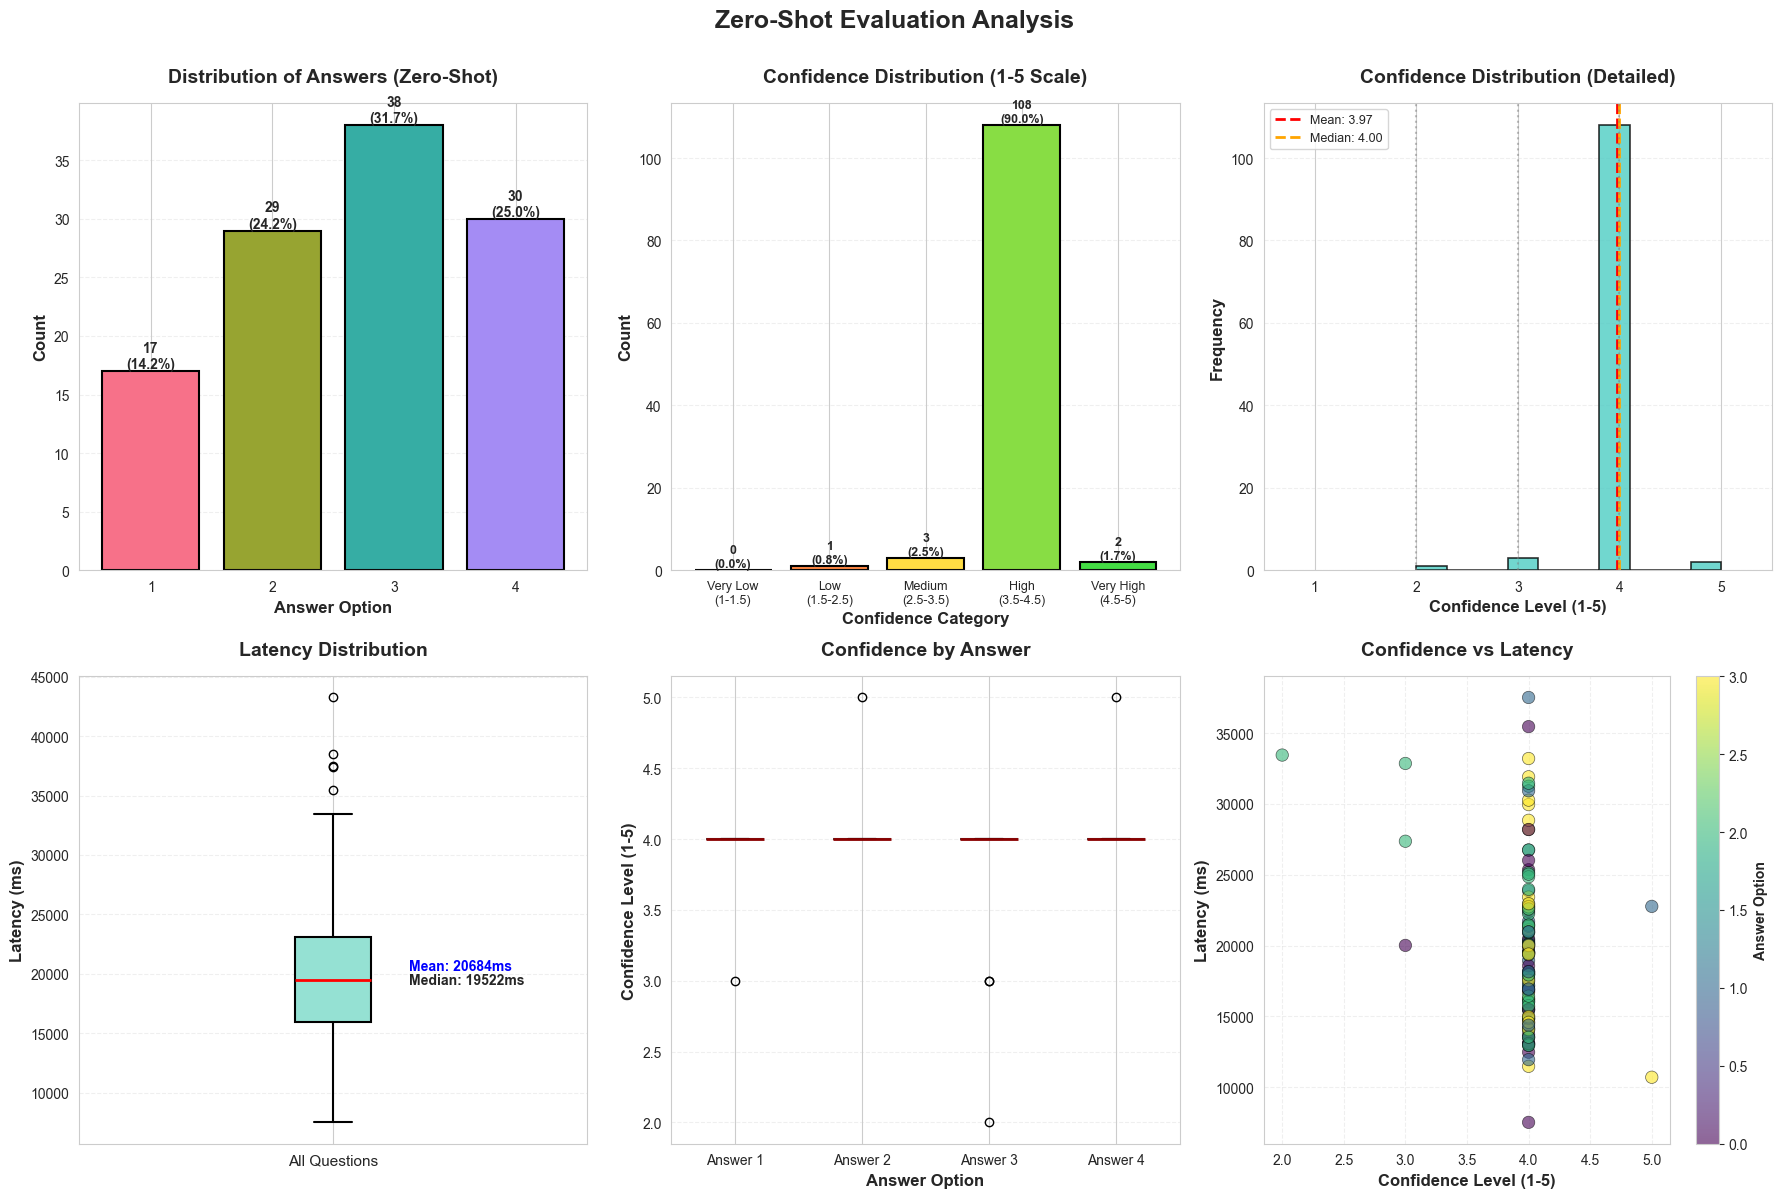


📊 Generating correlation heatmap...
   ✅ Heatmap saved: correlation_heatmap_zero_shot.png


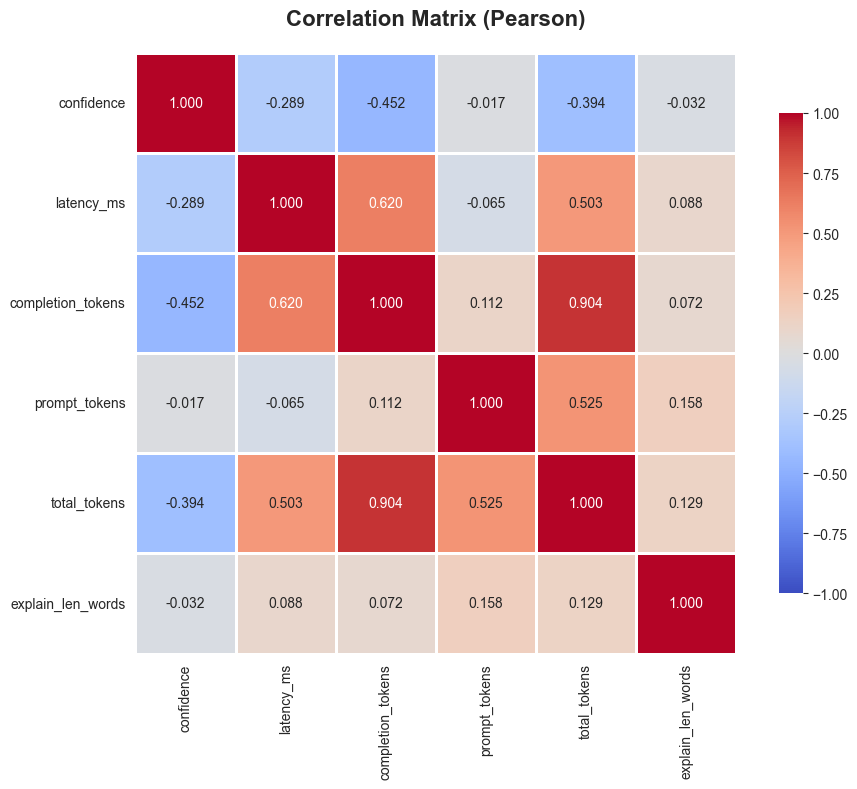


📊 Generating latency timeline...
   ✅ Timeline saved: latency_timeline_zero_shot.png


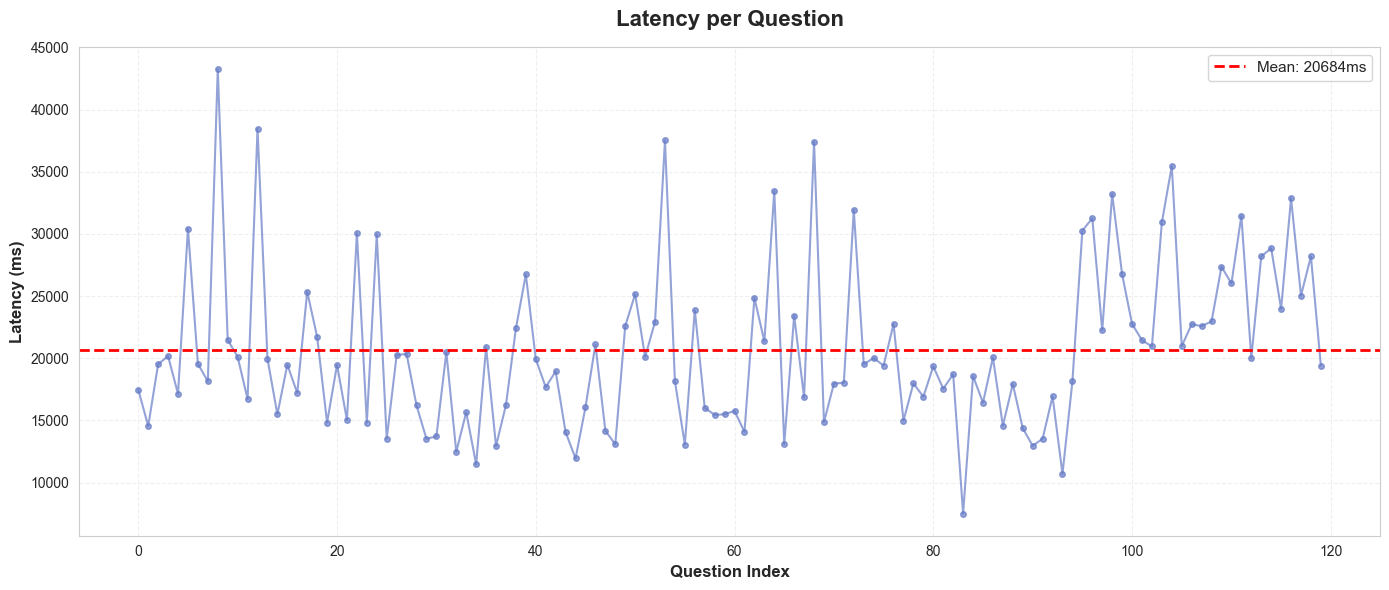

   ✅ Saved: tokens_vs_confidence.png


C:\Users\sazgar\AppData\Local\Temp\ipykernel_21636\3624510010.py:240: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, patch_artist=True,


   ✅ Saved: tokens_by_answer.png
   ✅ Saved: tokens_vs_latency.png
   ✅ Saved: explain_len_vs_confidence.png

✅ All visualizations generated successfully!


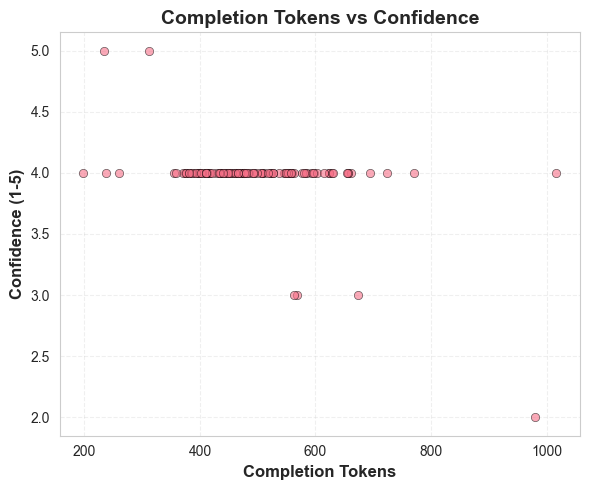

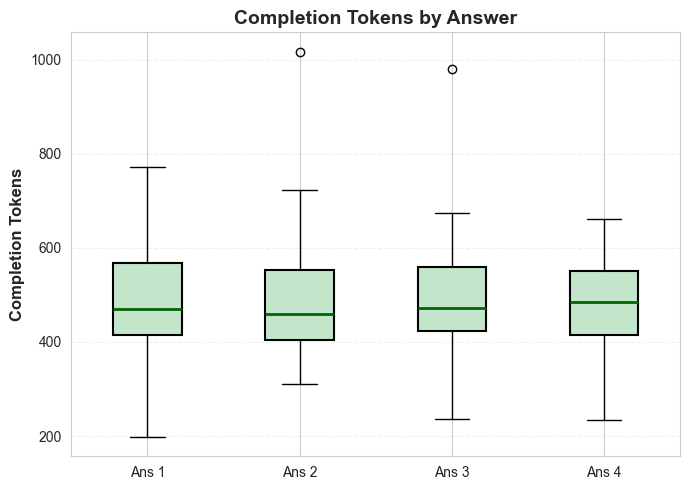

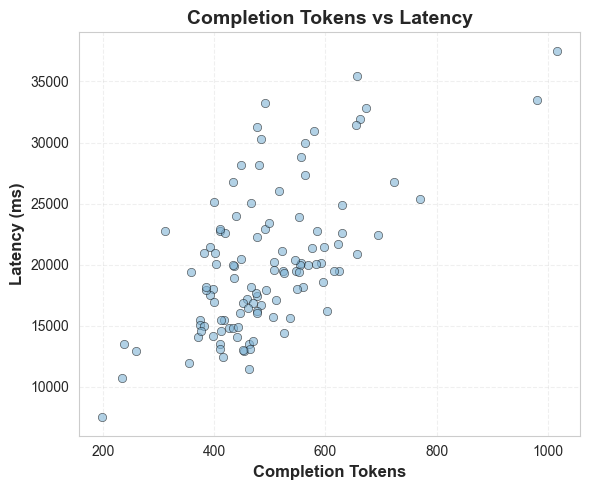

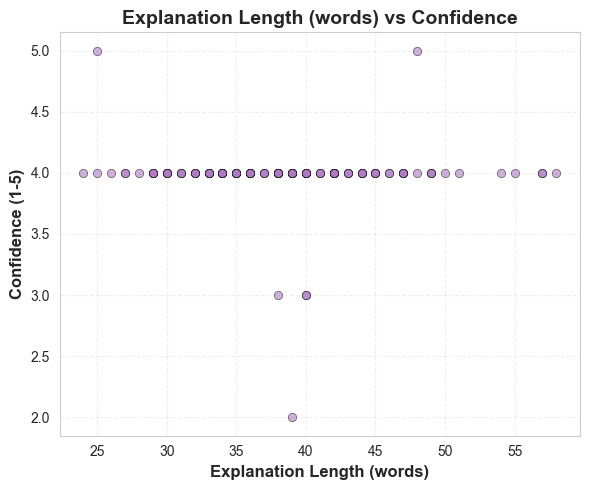

In [37]:
# تنظیمات نمایش فارسی
plt.rcParams['font.family'] = 'Arial'  # در صورت امکان فونت فارسی با پوشش کامل نصب شود
sns.set_style("whitegrid")
sns.set_palette("husl")

print("\n" + "="*70)
print("📊 Generating Visualizations")
print("="*70)

# ایجاد فیگور بزرگ با چند subplot
fig = plt.figure(figsize=(18, 12))

# ==================== نمودار 1: توزیع پاسخ نهایی ====================
ax1 = plt.subplot(2, 3, 1)
if 'answer' in results.columns and results['answer'].notna().any():
    answer_counts = results['answer'].dropna().astype(str).value_counts().sort_index()
    colors = sns.color_palette("husl", len(answer_counts))
    bars = ax1.bar(answer_counts.index.astype(str), answer_counts.values, color=colors,
                   edgecolor='black', linewidth=1.5)

    total_n = len(results)
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}\n({height/total_n*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax1.set_title('Distribution of Answers (Zero-Shot)', fontsize=14, fontweight='bold', pad=15)
    ax1.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax1.text(0.5, 0.5, 'No answers', ha='center', va='center', fontsize=12)
    ax1.axis('off')

# ==================== نمودار 2: توزیع Confidence ====================
ax2 = plt.subplot(2, 3, 2)
if 'confidence' in results.columns and results['confidence'].notna().any():
    confidence_bins = [0, 1.5, 2.5, 3.5, 4.5, 5.1]
    confidence_labels = ['Very Low\n(1-1.5)', 'Low\n(1.5-2.5)', 'Medium\n(2.5-3.5)', 'High\n(3.5-4.5)', 'Very High\n(4.5-5)']

    conf_cat = pd.cut(
        results['confidence'],
        bins=confidence_bins,
        labels=confidence_labels,
        include_lowest=True,
        right=False
    )
    conf_counts = conf_cat.value_counts().sort_index()

    colors_conf = ['#FF4444', '#FF8844', '#FFDD44', '#88DD44', '#44DD44']
    bars2 = ax2.bar(range(len(conf_counts)), conf_counts.values,
                    color=colors_conf[:len(conf_counts)],
                    edgecolor='black', linewidth=1.5)

    total_n = len(results)
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{int(height)}\n({height/total_n*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax2.set_xticks(range(len(conf_counts)))
    ax2.set_xticklabels(conf_counts.index, fontsize=9)
    ax2.set_title('Confidence Distribution (1-5 Scale)', fontsize=14, fontweight='bold', pad=15)
    ax2.set_xlabel('Confidence Category', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax2.text(0.5, 0.5, 'No confidence data', ha='center', va='center', fontsize=12)
    ax2.axis('off')

# ==================== نمودار 3: Histogram Confidence ====================
ax3 = plt.subplot(2, 3, 3)
if 'confidence' in results.columns and results['confidence'].notna().any():
    conf_vals = results['confidence'].dropna()
    ax3.hist(conf_vals, bins=10, color='#4ECDC4', edgecolor='black', linewidth=1.2, alpha=0.8)
    ax3.axvline(conf_vals.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {conf_vals.mean():.2f}')
    ax3.axvline(conf_vals.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {conf_vals.median():.2f}')

    for v in [2,3,4]:
        ax3.axvline(v, color='gray', linestyle=':', linewidth=1.5, alpha=0.5)

    ax3.set_title('Confidence Distribution (Detailed)', fontsize=14, fontweight='bold', pad=15)
    ax3.set_xlabel('Confidence Level (1-5)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9, loc='upper left')
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.set_xlim([0.5, 5.5])
else:
    ax3.text(0.5, 0.5, 'No confidence data', ha='center', va='center', fontsize=12)
    ax3.axis('off')

# ==================== نمودار 4: Boxplot Latency ====================
ax4 = plt.subplot(2, 3, 4)
if 'latency_ms' in results.columns and results['latency_ms'].notna().any():
    valid_latency = results['latency_ms'].dropna()
    ax4.boxplot(valid_latency, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#95E1D3', edgecolor='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                medianprops=dict(color='red', linewidth=2))

    ax4.set_title('Latency Distribution', fontsize=14, fontweight='bold', pad=15)
    ax4.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax4.set_xticklabels(['All Questions'], fontsize=11)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')

    median_lat = valid_latency.median()
    mean_lat = valid_latency.mean()
    ax4.text(1.15, median_lat, f'Median: {median_lat:.0f}ms', fontsize=10, fontweight='bold', va='center')
    ax4.text(1.15, mean_lat, f'Mean: {mean_lat:.0f}ms', fontsize=10, fontweight='bold', va='center', color='blue')
else:
    ax4.text(0.5, 0.5, 'No latency data', ha='center', va='center', fontsize=12)
    ax4.axis('off')

# ==================== نمودار 5: Confidence به تفکیک Answer ====================
ax5 = plt.subplot(2, 3, 5)
if 'answer' in results.columns and 'confidence' in results.columns:
    answer_conf_data = []
    answer_labels = []
    for ans in sorted(results['answer'].dropna().astype(str).unique()):
        conf_values = results.loc[results['answer'].astype(str) == ans, 'confidence'].dropna()
        if len(conf_values) > 0:
            answer_conf_data.append(conf_values)
            answer_labels.append(f'Answer {ans}')

    if len(answer_conf_data) > 0:
        ax5.boxplot(answer_conf_data, labels=answer_labels, patch_artist=True,
                    boxprops=dict(facecolor='#FFB6B9', alpha=0.7, edgecolor='black', linewidth=1.5),
                    whiskerprops=dict(color='black', linewidth=1.5),
                    capprops=dict(color='black', linewidth=1.5),
                    medianprops=dict(color='darkred', linewidth=2))

        ax5.set_title('Confidence by Answer', fontsize=14, fontweight='bold', pad=15)
        ax5.set_xlabel('Answer Option', fontsize=12, fontweight='bold')
        ax5.set_ylabel('Confidence Level (1-5)', fontsize=12, fontweight='bold')
        ax5.grid(axis='y', alpha=0.3, linestyle='--')
    else:
        ax5.text(0.5, 0.5, 'No per-answer data', ha='center', va='center', fontsize=12)
        ax5.axis('off')
else:
    ax5.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
    ax5.axis('off')

# ==================== نمودار 6: Scatter Confidence vs Latency ====================
ax6 = plt.subplot(2, 3, 6)
required_cols = {'confidence','latency_ms','answer'}
if required_cols.issubset(results.columns) and results[list(required_cols)].notna().all(axis=1).any():
    valid_data = results.dropna(subset=list(required_cols)).copy()
    valid_data['answer_str'] = valid_data['answer'].astype(str)
    scatter = ax6.scatter(valid_data['confidence'], valid_data['latency_ms'],
                          c=valid_data['answer_str'].astype('category').cat.codes,
                          cmap='viridis', s=80, alpha=0.6, edgecolors='black', linewidth=0.5)
    ax6.set_title('Confidence vs Latency', fontsize=14, fontweight='bold', pad=15)
    ax6.set_xlabel('Confidence Level (1-5)', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax6.grid(alpha=0.3, linestyle='--')
    cbar = plt.colorbar(scatter, ax=ax6)
    cbar.set_label('Answer Option', fontsize=10, fontweight='bold')
else:
    ax6.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', fontsize=12)
    ax6.axis('off')

# ==================== تنظیمات کلی ====================
plt.suptitle('Zero-Shot Evaluation Analysis', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.99])

viz_filename = 'visualizations_zero_shot.png'
plt.savefig(viz_filename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ Visualization saved: {viz_filename}")
plt.show()

# ==================== نمودارهای اضافی ====================

# 7) Heatmap همبستگی (Pearson + گزینه افزودن Spearman)
print("\n📊 Generating correlation heatmap...")
fig2, ax7 = plt.subplots(figsize=(10, 8))
numeric_cols = [c for c in ['confidence','latency_ms','completion_tokens','prompt_tokens','total_tokens','explain_len_words'] if c in results.columns]
if len(numeric_cols) >= 2:
    corr_data = results[numeric_cols].corr(method='pearson')
    sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=2, cbar_kws={"shrink": 0.8},
                ax=ax7, vmin=-1, vmax=1)
    ax7.set_title('Correlation Matrix (Pearson)', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    heatmap_filename = 'correlation_heatmap_zero_shot.png'
    plt.savefig(heatmap_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Heatmap saved: {heatmap_filename}")
    plt.show()
else:
    print("   ⚠️  Not enough numeric columns for correlation matrix")

# 8) Timeline latency
print("\n📊 Generating latency timeline...")
fig3, ax8 = plt.subplots(figsize=(14, 6))
if 'latency_ms' in results.columns and results['latency_ms'].notna().any():
    valid_latency_timeline = results['latency_ms'].dropna()
    ax8.plot(valid_latency_timeline.index, valid_latency_timeline,
             marker='o', linestyle='-', linewidth=1.5, markersize=4,
             color='#667BC6', alpha=0.7)
    ax8.axhline(valid_latency_timeline.mean(),
                color='red', linestyle='--', linewidth=2,
                label=f'Mean: {valid_latency_timeline.mean():.0f}ms')
    ax8.set_title('Latency per Question', fontsize=16, fontweight='bold', pad=15)
    ax8.set_xlabel('Question Index', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
    ax8.legend(fontsize=11)
    ax8.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    timeline_filename = 'latency_timeline_zero_shot.png'
    plt.savefig(timeline_filename, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Timeline saved: {timeline_filename}")
    plt.show()
else:
    print("   ⚠️  No latency data")

# 9) Scatter: completion_tokens vs confidence
if {'completion_tokens','confidence'}.issubset(results.columns):
    sub = results.dropna(subset=['completion_tokens','confidence'])
    if len(sub) > 0:
        plt.figure(figsize=(6,5))
        plt.scatter(sub['completion_tokens'], sub['confidence'], alpha=0.6, edgecolors='black', linewidths=0.5)
        plt.title('Completion Tokens vs Confidence', fontsize=14, fontweight='bold')
        plt.xlabel('Completion Tokens', fontsize=12, fontweight='bold')
        plt.ylabel('Confidence (1-5)', fontsize=12, fontweight='bold')
        plt.grid(alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig('tokens_vs_confidence.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("   ✅ Saved: tokens_vs_confidence.png")

# 10) Boxplot: completion_tokens by answer
if {'completion_tokens','answer'}.issubset(results.columns):
    grp = results.dropna(subset=['completion_tokens','answer']).copy()
    if len(grp) > 0:
        plt.figure(figsize=(7,5))
        ans_order = sorted(grp['answer'].astype(str).unique())
        data = [grp.loc[grp['answer'].astype(str)==a, 'completion_tokens'] for a in ans_order]
        labels = [f'Ans {a}' for a in ans_order]
        plt.boxplot(data, labels=labels, patch_artist=True,
                    boxprops=dict(facecolor='#C3E6CB', edgecolor='black', linewidth=1.5),
                    medianprops=dict(color='darkgreen', linewidth=2))
        plt.title('Completion Tokens by Answer', fontsize=14, fontweight='bold')
        plt.ylabel('Completion Tokens', fontsize=12, fontweight='bold')
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig('tokens_by_answer.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("   ✅ Saved: tokens_by_answer.png")

# 11) Scatter: completion_tokens vs latency
if {'completion_tokens','latency_ms'}.issubset(results.columns):
    sub = results.dropna(subset=['completion_tokens','latency_ms'])
    if len(sub) > 0:
        plt.figure(figsize=(6,5))
        plt.scatter(sub['completion_tokens'], sub['latency_ms'], alpha=0.6, color='#7FB3D5',
                    edgecolors='black', linewidths=0.5)
        plt.title('Completion Tokens vs Latency', fontsize=14, fontweight='bold')
        plt.xlabel('Completion Tokens', fontsize=12, fontweight='bold')
        plt.ylabel('Latency (ms)', fontsize=12, fontweight='bold')
        plt.grid(alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig('tokens_vs_latency.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("   ✅ Saved: tokens_vs_latency.png")

# 12) Scatter: explanation length vs confidence
if {'explain_len_words','confidence'}.issubset(results.columns):
    sub = results.dropna(subset=['explain_len_words','confidence'])
    if len(sub) > 0:
        plt.figure(figsize=(6,5))
        plt.scatter(sub['explain_len_words'], sub['confidence'], alpha=0.6, color='#AF7AC5',
                    edgecolors='black', linewidths=0.5)
        plt.title('Explanation Length (words) vs Confidence', fontsize=14, fontweight='bold')
        plt.xlabel('Explanation Length (words)', fontsize=12, fontweight='bold')
        plt.ylabel('Confidence (1-5)', fontsize=12, fontweight='bold')
        plt.grid(alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.savefig('explain_len_vs_confidence.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("   ✅ Saved: explain_len_vs_confidence.png")

print("\n" + "="*70)
print("✅ All visualizations generated successfully!")
print("="*70)